# Week 3: Live Coverage Lookups with the RadioLand API

**NWR Coverage Gap Research — Summer 2026**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/W2NJL/nwr-gap-research/blob/main/week3_radioland_api.ipynb)

---

In Week 1 you explored `wx_stations.csv` — a snapshot of where NWR transmitters sit. In Week 2 you inventoried the external datasets that will tell us *who* lives near those transmitters and *what hazards* they face.

But neither of those told you something critical: **given a specific address or coordinate, what NWR signal can a receiver actually pick up there?**

That question requires a propagation model — a calculation that accounts for transmitter power, antenna height, frequency, and distance to estimate real-world signal strength at a point. This week you'll use the **RadioLand API** to run those calculations programmatically, building the core tool you'll need for the gap analysis in Weeks 4–7.

**Learning goals:**
- Understand what Server-Sent Events (SSE) are and how to consume them in Python
- Call the RadioLand API for any lat/lon and get back a ranked list of receivable NWR stations
- Interpret field strength values and establish a working coverage threshold
- Query multiple locations and start identifying which cities lack adequate coverage

---
## Part 1: Setup

In [2]:
import requests
import json
import io
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from IPython.display import display

WX_URL     = "https://raw.githubusercontent.com/CSC-2053-Spring-26-100/lab-12-finding-the-weather-radio-gaps/main/wx_stations.csv"
CITIES_URL = "https://raw.githubusercontent.com/CSC-2053-Spring-26-100/lab-12-finding-the-weather-radio-gaps/main/us_cities.csv"

wx     = pd.read_csv(WX_URL)
wx     = wx[wx['country'] == 'USA'].copy()
wx['longitude'] = -wx['longitude'].abs()   # ensure negative for western hemisphere

cities = pd.read_csv(CITIES_URL)

print(f"Loaded {len(wx)} NWR stations and {len(cities)} cities.")

Loaded 1033 NWR stations and 4834 cities.


---
## Part 2: How the RadioLand API Works

### What is RadioLand?

RadioLand is an internal research tool built on top of FCC and NOAA station databases. Given a latitude and longitude, it runs an ITM (Irregular Terrain Model) propagation calculation for every NWR transmitter within range and returns a ranked list showing which stations are receivable — and how strong.

The base URL is:
```
http://52.151.197.43/search_stream
```

### Key Parameters

| Parameter | What it does |
|---|---|
| `lat`, `lon` | The receiver location you're querying |
| `broadcastBand` | `WX` for NOAA Weather Radio (NWR); others exist for FM, AM |
| `rxHeight` | Receiver antenna height above ground in meters (10 = typical home receiver) |
| `sig_strength` | Minimum field strength threshold; stations below this are excluded |
| `model` | Propagation model: `ml` uses a machine-learning-enhanced ITM calculation |
| `measurementUnit` | `metric` returns distances in km, field strength in dB(µV/m) |

### What is SSE?

Unlike a regular API that returns all results at once, this endpoint uses **Server-Sent Events (SSE)** — it streams a series of progress updates while it works, then delivers the final result when done. Each message looks like:

```
data: {"type": "progress", "percentage": 22, "message": "Calculating distances..."}

data: {"type": "complete", "percentage": 100, "data": "{...full station JSON...}"}
```

In Python, you consume it by opening the connection with `stream=True` and reading line by line until you hit the `complete` event.

---
## Part 3: The Query Function

Run the cell below — it defines `query_nwr_coverage()`, the core function you'll use throughout this notebook and in future weeks.

In [1]:
RADIOLAND_BASE = "http://52.151.197.43/search_stream"

def query_nwr_coverage(lat, lon, rx_height=10, min_sig_strength=3, verbose=True):
    """
    Query the RadioLand API for NWR stations receivable at (lat, lon).

    Returns a DataFrame with one row per receivable station, sorted by
    field_strength descending. Returns None if the request fails.

    Parameters
    ----------
    lat, lon        : float  — receiver coordinates (lon should be negative for western US)
    rx_height       : int    — receiver antenna height above ground in meters
    min_sig_strength: int    — minimum signal threshold (3 = default per RadioLand)
    verbose         : bool   — print progress messages
    """
    params = {
        "lat": lat,
        "lon": lon,
        "search_freq": "none",
        "callsign": "none",
        "request_type": 1,
        "pi_code": "none",
        "sig_strength": min_sig_strength,
        "am_sig_strength": 2,
        "startMiles": "none",
        "miles": "null",
        "slogan": "none",
        "owner": "none",
        "format": "none",
        "wfo": "none",
        "rxHeight": rx_height,
        "mlbTeam": "none",
        "market": "none",
        "country": "none",
        "sp": "none",
        "measurementUnit": "metric",
        "locationName": "",
        "broadcastBand": "WX",
        "timeOfDay": "day",
        "model": "ml"
    }

    try:
        resp = requests.get(RADIOLAND_BASE, params=params, stream=True, timeout=90)
        resp.raise_for_status()
    except requests.RequestException as e:
        print(f"Request failed: {e}")
        return None

    for raw_line in resp.iter_lines():
        if not raw_line:
            continue
        line = raw_line.decode('utf-8')
        if not line.startswith('data: '):
            continue

        event = json.loads(line[6:])

        if event.get('type') == 'progress' and verbose:
            print(f"  [{event['percentage']:>3}%] {event['message']}", end='\r')

        elif event.get('type') == 'complete':
            if verbose:
                print(f"  [100%] Done.                                        ")
            result = json.loads(event['data'])
            df = pd.DataFrame(result['data'])
            if df.empty:
                return df
            # The API returns positive longitudes for western-hemisphere stations — negate them
            for col in ['lon', 'transmitter_lon']:
                if col in df.columns:
                    df[col] = -df[col].abs()
            df = df.sort_values('field_strength', ascending=False).reset_index(drop=True)
            return df

    return None

print("query_nwr_coverage() is ready.")

query_nwr_coverage() is ready.


---
## Part 4: Your First Query

Let's test the function with a known location: **Tabernacle, NJ** — a rural township in Burlington County. Run the cell and watch the progress stream in.

In [3]:
LAT_TABERNACLE = 39.8732265
LON_TABERNACLE = -74.664345740625

print("Querying RadioLand for Tabernacle, NJ...")
tabernacle = query_nwr_coverage(LAT_TABERNACLE, LON_TABERNACLE)

print(f"\n{len(tabernacle)} receivable NWR stations found.")
tabernacle[['callsign', 'city', 'sp', 'frequency', 'distance', 'field_strength', 'wfo']].head(10)

Querying RadioLand for Tabernacle, NJ...
  [100%] Done.                                        

59 receivable NWR stations found.


,callsign,city,sp,frequency,distance,field_strength,wfo
0,KIH-28,PHILADELPHIA,PA,162.475,26.86,56.450050,Philadelphia-Mt Holly NJ
1,KHB-38,ATLANTIC CITY,NJ,162.400,36.08,39.879662,Philadelphia-Mt Holly NJ
2,WXM-60,SOUTHARD,NJ,162.450,29.76,39.595394,Philadelphia-Mt Holly NJ
3,WXL-39,ALLENTOWN,PA,162.400,62.94,31.005783,Philadelphia-Mt Holly NJ
4,WNG-704,HIBERNIA PARK,PA,162.425,61.71,28.625563,Philadelphia-Mt Holly NJ
5,KWO-35,NEW YORK CITY,NY,162.550,70.23,26.019745,New York NY
6,KZZ-31,HARDYSTON,NJ,162.500,88.02,23.188379,Philadelphia-Mt Holly NJ
7,WXK-97,SUDLERSVILLE,MD,162.500,82.41,21.352339,Philadelphia-Mt Holly NJ
8,WXL-43,WILKES-BARRE,PA,162.550,110.45,21.145458,Binghamton NY
9,WXL-40,HARRISBURG,PA,162.550,120.95,20.657717,State College PA


---
## Part 5: Understanding Field Strength

The `field_strength` column is returned in **dB(µV/m)** — decibels relative to one microvolt per meter. This is the standard unit for VHF/UHF signal strength in broadcasting.

RadioLand's ML-enhanced propagation model produces higher values than classic ITM contour predictions, so the relevant scale for interpreting its output is:

| Field Strength | Interpretation |
|---|---|
| ≥ 60 dB(µV/m) | Strong — excellent reception on any receiver |
| 50–60 dB(µV/m) | Suitable — reliable reception under normal conditions |
| 40–50 dB(µV/m) | Marginal — may work but not dependable for emergency alerts |
| < 40 dB(µV/m) | Poor — unreliable; effectively a coverage gap |

For this research project, we'll define **covered** as: the *best available* NWR station at a location delivers **≥ 50 dB(µV/m)**. You may want to revisit this threshold as you dig into the literature — note any FCC or NOAA standards you find that speak to minimum receivable field strength for public alerting.

### E1 — Tabernacle Coverage Profile

Use the `tabernacle` DataFrame to answer:

1. What is the strongest station (highest `field_strength`) receivable at Tabernacle? What's its callsign, city, and frequency? - callsign KIH-28 city PHILADELPHIA frequency 162.475
2. How many stations exceed the 20 dB threshold? How many fall below 10 dB? - 10 above, 5 below
3. Is Tabernacle "covered" under our definition? - Yes
4. What WFO is responsible for the strongest signal? Does that match the geography? - Philadelphia-Mt Holly NJ, Yes it does as the city is in the philly jersey area.

In [17]:
COVERAGE_THRESHOLD = 50.0   # dB(µV/m) — change this to experiment (>60 = strong, 50-60 = suitable, <40 = poor)

print(tabernacle.loc[tabernacle['field_strength'].idxmax()][['callsign', 'city', 'frequency']])

print((tabernacle['field_strength'] > 20).sum())
print((tabernacle['field_strength'] < 10).sum())

print(tabernacle.loc[tabernacle['field_strength'].idxmax()]['field_strength'] >= COVERAGE_THRESHOLD)

print(tabernacle.loc[tabernacle['field_strength'].idxmax()]['wfo'])


callsign           KIH-28
city         PHILADELPHIA
frequency         162.475
Name: 0, dtype: object
10
5
True
Philadelphia-Mt Holly NJ


### E2 — Field Strength vs. Distance

Plot `field_strength` (y-axis) against `distance` (x-axis) for all stations returned for Tabernacle. Add a horizontal dashed line at your coverage threshold.

Questions:
1. Is the relationship between distance and field strength perfectly linear? Why or why not? - No it is not. It drops as distance gets larger but field strenth depends on more than just distance.
2. Are there any outliers — stations that are far away but still strong, or close but weak? What might explain that? - the two points around 30–35 km sitting at 40 dB are as close in distance to KIH-28 but far weaker. This is most likely because of transmitter power and what direction they are in as well as what geography is in the way. These two stations are likely close to each other and have similar power.

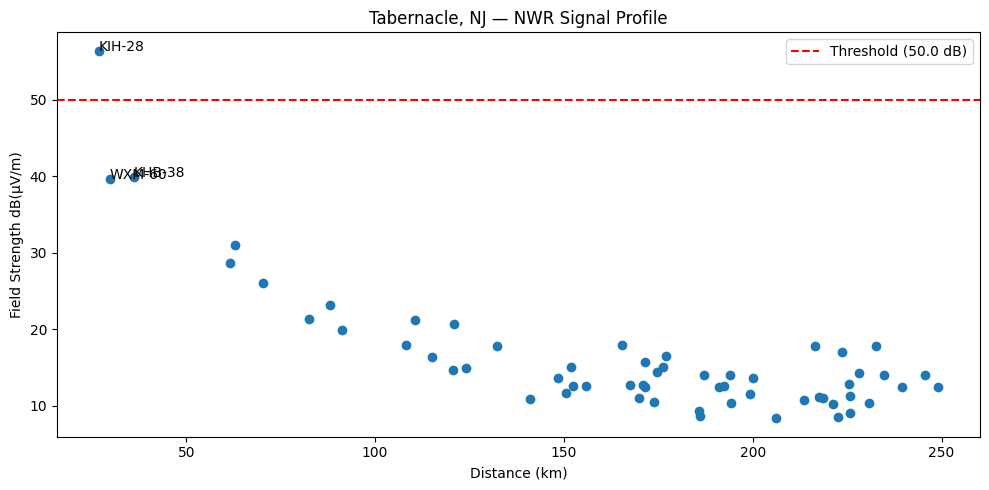

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

# YOUR CODE HERE
# Scatter plot of distance vs field_strength
# Add a horizontal line at COVERAGE_THRESHOLD
# Label the top 3 stations by name (callsign)

top3 = tabernacle.nlargest(3, 'field_strength')

ax.scatter(tabernacle['distance'], tabernacle['field_strength'])
for _, row in top3.iterrows():
    ax.annotate(row['callsign'], (row['distance'], row['field_strength']))

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Field Strength dB(µV/m)')
ax.set_title('Tabernacle, NJ — NWR Signal Profile')
ax.axhline(COVERAGE_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({COVERAGE_THRESHOLD} dB)')
ax.legend()
plt.tight_layout()
plt.show()

### E3 — Frequency Mix

NWR uses 7 frequencies (162.400–162.550 MHz in 25 kHz steps). For the Tabernacle results:

1. Which frequencies are represented? - All 7 frequencies are represented.
2. How many stations are on each frequency? Do any frequencies have more coverage overlap than others? - 162.550    12
162.400    11
162.475    11
162.425     8
162.450     6
162.500     6
162.525     5
162.475-550 have the most stations and have a signifigant gap over the other 4.
3. Why does it matter if two strong stations share the same frequency? (Hint: look at the `Interference` column — it's empty here, but think about what it would show if it weren't.) - A reciever can only tune to one frequency at a time so if two strong stations share a frequency then they can create interference and you will not be able to clearly recieve emergency messages.

In [23]:
print(tabernacle['frequency'].unique())

print(tabernacle['frequency'].value_counts())

print(tabernacle['Interference'])

[162.475 162.4   162.45  162.425 162.55  162.5   162.525]
frequency
162.550    12
162.400    11
162.475    11
162.425     8
162.450     6
162.500     6
162.525     5
Name: count, dtype: int64
0     []
1     []
2     []
3     []
4     []
5     []
6     []
7     []
8     []
9     []
10    []
11    []
12    []
13    []
14    []
15    []
16    []
17    []
18    []
19    []
20    []
21    []
22    []
23    []
24    []
25    []
26    []
27    []
28    []
29    []
30    []
31    []
32    []
33    []
34    []
35    []
36    []
37    []
38    []
39    []
40    []
41    []
42    []
43    []
44    []
45    []
46    []
47    []
48    []
49    []
50    []
51    []
52    []
53    []
54    []
55    []
56    []
57    []
58    []
Name: Interference, dtype: object


---
## Part 6: Querying Multiple Locations

A single location query is useful for spot-checking, but our eventual goal is to classify thousands of US cities. Here you'll build a small batch query to practice the pattern.

> **Note on API etiquette:** Each call takes 15–30 seconds and runs a real propagation model. Add a short sleep between requests and limit batch sizes during development. For the large-scale city sweep in Week 5, we'll discuss a more efficient approach.

In [24]:
def get_best_signal(lat, lon, threshold=COVERAGE_THRESHOLD):
    """
    Query RadioLand and return a summary dict for one location.
    Returns None if the request fails.
    """
    df = query_nwr_coverage(lat, lon, verbose=False)
    if df is None or df.empty:
        return {'best_callsign': None, 'best_field_strength': 0.0,
                'stations_above_threshold': 0, 'covered': False}

    best = df.iloc[0]
    return {
        'best_callsign':            best['callsign'],
        'best_field_strength':      round(best['field_strength'], 2),
        'best_distance_km':         round(best['distance'], 1),
        'best_wfo':                 best.get('wfo', None),
        'stations_above_threshold': int((df['field_strength'] >= threshold).sum()),
        'covered':                  bool(best['field_strength'] >= threshold),
    }

print("get_best_signal() is ready.")

get_best_signal() is ready.


### E4 — Query a Sample of Cities

The cell below selects a small sample of US cities and queries coverage for each. Choose the sample to include a mix of rural and urban locations, different regions, and varying population sizes.

The sampling approach is up to you — you could take the 10 smallest cities by population, or 2 cities from each of 5 states, or all cities in a specific state you care about. Justify your choice in a comment.

In [25]:
# --- Build your sample ---
# YOUR CODE HERE — create a DataFrame called `sample` with columns:
#   city, state_id, lat, lng, population
# Keep it to 10-15 rows to avoid a very long runtime.
#
# Example (uncomment and modify):
# sample = cities[cities['state_id'] == 'WY'].nsmallest(10, 'population')

fl = cities[cities['state_id'] == 'FL']
sample = pd.concat([fl.nlargest(5, 'population'), fl.nsmallest(5, 'population')])[['city', 'state_id', 'lat', 'lng', 'population']]

print(sample[['city', 'state_id', 'lat', 'lng', 'population']])

               city state_id      lat      lng  population
450           Miami       FL  25.7840 -80.2102   6247425.0
528           Tampa       FL  27.9937 -82.4454   2744107.0
422         Orlando       FL  28.4801 -81.3448   1757288.0
597    Jacksonville       FL  30.3322 -81.6749   1141459.0
417        Sarasota       FL  27.3391 -82.5439    701487.0
429      Valparaiso       FL  30.4926 -86.5079      5072.0
501    Kenneth City       FL  27.8156 -82.7162      5101.0
416       South Bay       FL  26.6783 -80.7268      5111.0
566  South Pasadena       FL  27.7524 -82.7395      5111.0
391        Mascotte       FL  28.6110 -81.9107      5538.0


In [26]:
# --- Run the batch query ---
# Don't modify this cell — just run it after defining `sample` above.

results = []

for _, row in sample.iterrows():
    label = f"{row['city']}, {row['state_id']}"
    print(f"Querying {label}...", end=' ')
    summary = get_best_signal(row['lat'], row['lng'])
    if summary:
        summary['city']       = row['city']
        summary['state_id']   = row['state_id']
        summary['lat']        = row['lat']
        summary['lng']        = row['lng']
        summary['population'] = row.get('population', None)
        results.append(summary)
        status = 'COVERED' if summary['covered'] else 'GAP'
        print(f"{status} — best: {summary['best_callsign']} @ {summary['best_field_strength']} dB")
    else:
        print("FAILED")
    time.sleep(2)   # be polite to the API

coverage_df = pd.DataFrame(results)
print(f"\nDone. {coverage_df['covered'].sum()} of {len(coverage_df)} cities covered.")
coverage_df

Querying Miami, FL... COVERED — best: WZ-2531 @ 75.06 dB
Querying Tampa, FL... COVERED — best: KHB-32 @ 71.3 dB
Querying Orlando, FL... COVERED — best: KIH-63 @ 73.07 dB
Querying Jacksonville, FL... COVERED — best: KHB-39 @ 78.12 dB
Querying Sarasota, FL... COVERED — best: WWG-59 @ 66.78 dB
Querying Valparaiso, FL... GAP — best: KEC-86 @ 40.15 dB
Querying Kenneth City, FL... COVERED — best: KEC-38 @ 86.94 dB
Querying South Bay, FL... COVERED — best: WXM-58 @ 75.06 dB
Querying South Pasadena, FL... COVERED — best: KEC-38 @ 80.52 dB
Querying Mascotte, FL... COVERED — best: KPS-505 @ 63.53 dB

Done. 9 of 10 cities covered.


,best_callsign,best_field_strength,best_distance_km,best_wfo,stations_above_threshold,covered,city,state_id,lat,lng,population
0,WZ-2531,75.06,6.4,None,3,True,Miami,FL,25.7840,-80.2102,6247425.0
1,KHB-32,71.30,15.4,Tampa Bay Area FL,2,True,Tampa,FL,27.9937,-82.4454,2744107.0
2,KIH-63,73.07,9.0,Melbourne FL,1,True,Orlando,FL,28.4801,-81.3448,1757288.0
3,KHB-39,78.12,7.6,Jacksonville FL,1,True,Jacksonville,FL,30.3322,-81.6749,1141459.0
4,WWG-59,66.78,16.9,Tampa Bay Area FL,1,True,Sarasota,FL,27.3391,-82.5439,701487.0
5,KEC-86,40.15,34.1,Mobile AL,0,False,Valparaiso,FL,30.4926,-86.5079,5072.0
6,KEC-38,86.94,3.6,Tampa Bay Area FL,2,True,Kenneth City,FL,27.8156,-82.7162,5101.0
7,WXM-58,75.06,5.7,Miami FL,1,True,South Bay,FL,26.6783,-80.7268,5111.0
8,KEC-38,80.52,6.8,Tampa Bay Area FL,2,True,South Pasadena,FL,27.7524,-82.7395,5111.0
9,KPS-505,63.53,13.9,Tampa Bay Area FL,1,True,Mascotte,FL,28.6110,-81.9107,5538.0


### E5 — Analyze Your Sample Results

Using `coverage_df`:

1. Which city in your sample has the weakest coverage (lowest `best_field_strength`)? What factors might explain it? - Valparasio has the weakest coverage. This is probably because its best distance is significantly larger than any of the other stations. That area of the state is also much more rural.
2. Is there a pattern between `population` and coverage quality? (A scatter plot might help.) - No real clear pattern in my dataset.
3. Are any uncovered cities surprising? Are any covered cities surprising? - Valparaiso being the only uncovered city is kind of expected. I am shocked that the other small towns are so covered, some more than Tampa and Miami.
4. What limitations does this 10–15 city sample have for drawing conclusions? - This sample is in Florida where hurricanes are common and more NWR transmitters will liekly be. This dataset is also not really spread out by land coverage, especially the smaller ciites. I should include a lot mroe smaller cities.

city                   Valparaiso
best_field_strength         40.15
best_distance_km             34.1
Name: 5, dtype: object


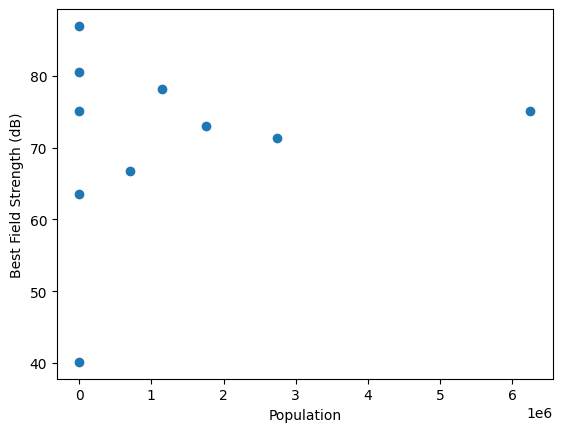

             city  population  best_field_strength  covered
0           Miami   6247425.0                75.06     True
1           Tampa   2744107.0                71.30     True
2         Orlando   1757288.0                73.07     True
3    Jacksonville   1141459.0                78.12     True
4        Sarasota    701487.0                66.78     True
5      Valparaiso      5072.0                40.15    False
6    Kenneth City      5101.0                86.94     True
7       South Bay      5111.0                75.06     True
8  South Pasadena      5111.0                80.52     True
9        Mascotte      5538.0                63.53     True


In [30]:
print(coverage_df.loc[coverage_df['best_field_strength'].idxmin()][['city', 'best_field_strength', 'best_distance_km']])

fig, ax = plt.subplots()
ax.scatter(coverage_df['population'], coverage_df['best_field_strength'])
ax.set_xlabel('Population')
ax.set_ylabel('Best Field Strength (dB)')
plt.show()

print(coverage_df[['city', 'population', 'best_field_strength', 'covered']])



---
## Part 7: Coverage Map

Build a Folium map showing your queried cities. Use:
- Green circles for covered cities
- Red circles for gap cities
- Popup showing city name, state, best signal, and whether it's covered

In [32]:
m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles='CartoDB positron')

for _, row in coverage_df.iterrows():
    color = 'green' if row['covered'] else 'red'
    popup = f"{row['city']}, {row['state_id']}<br>{row['best_callsign']} @ {row['best_field_strength']} dB"
    folium.CircleMarker(location=[row['lat'], row['lng']], color=color, fill=True, popup=popup).add_to(m)

display(m)

---
## Part 8: Connecting Back to Week 2

In Week 2 you loaded (or read about) the USDA Rural-Urban Continuum Codes (RUCC). The hypothesis is: **rural areas are more likely to be NWR gaps**.

Here's a simple test of that using your sample. If you have RUCC data loaded, join it to `coverage_df` and compare average field strength across metro vs. non-metro counties. If you don't have it loaded yet, write the code as pseudocode and describe what you'd expect to find.

In [34]:
rucc = pd.read_excel('/content/sample_data/Ruralurbancontinuumcodes2023.xlsx')
rucc['County_Name'] = rucc['County_Name'].str.replace(' County', '', regex=False)

coverage_df = coverage_df.merge(cities[['city', 'state_id', 'county_name']], on=['city', 'state_id'], how='left')

rucc_joined = coverage_df.merge(
    rucc[['State', 'County_Name', 'RUCC_2023']],
    left_on=['state_id', 'county_name'],
    right_on=['State', 'County_Name'],
    how='left'
)
print(rucc_joined.groupby('RUCC_2023')['best_field_strength'].mean())

RUCC_2023
1.0    75.450
2.0    53.465
Name: best_field_strength, dtype: float64


---
## Week 3 Reflection

Write brief answers below.

1. What does the RadioLand API give you that `wx_stations.csv` alone does not?
2. The 20 dB threshold is a starting assumption. What sources or standards would you look at to validate or revise it?
3. Two cities could both be "covered" (≥ 20 dB) but one gets 21 dB from a single station and the other gets 45 dB from three stations. Does that difference matter for emergency alerting? Why?
4. What's the biggest challenge you anticipate when scaling this query from 15 cities to 4,000+ cities in Week 5?

**Your answers:**

1. It gives us actual predicted signal strenth at any specific point. wx_stations.csv only tells us where the stations are and not who can pick them up.

2. FCC/NOAA standards and minimums would be useful. NWR documentation as well.

3. Yes, it matters a lot. There is redundancy in the city with three stations giving coverage with more reliable coverage. Even if one transmitter fails, they can still get coverage from others.

4. The runtime of the queries. If eqch query can take up to 30 seconds and we have thousands, that means a lot of hours.